# slakonet end-to-end demo

Runs every analysis task on a single JID from JARVIS-DFT and displays the interactive Plotly figures inline. In Colab you may need:

```python
!pip install -q slakonet jarvis-tools plotly scikit-image
```

In [8]:
!pwd

/home/kamalch/Software/ollama311/slakonet/slakonet/examples


In [1]:
from slakonet.examples.full_demo import task_bands_dos
from slakonet.optim import default_model, get_atoms
from slakonet.optim import (
    MultiElementSkfParameterOptimizer,
    get_atoms,
    kpts_to_klines,
    default_model,
)
model = default_model()
# model_path = '../tests/Si_only.pt'
# model = MultiElementSkfParameterOptimizer.load_ultra_compact(model_path
# )
# # model.float()
# # model=model.half()
# model.eval()

Loading cached model from /home/kamalch/.cache/atomgptlab/slakonet/slakonet_v0/slakonet_v0.pt
✅ Compact model loaded from: /home/kamalch/.cache/atomgptlab/slakonet/slakonet_v0/slakonet_v0.pt
Total time: 22.65s


In [2]:
atoms, _, _ = get_atoms('JVASP-943')
atoms=atoms.get_conventional_atoms

Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.


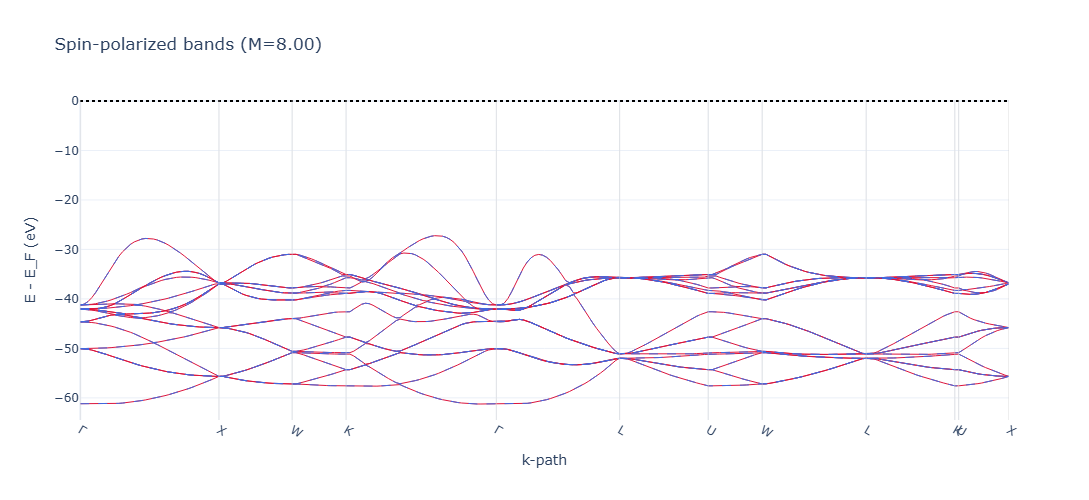

  wrote demo_spin.html  (total moment 8.000)


In [3]:
from slakonet.examples.full_demo import task_spin
x=task_spin(atoms,model,out='demo')

potential_energy tensor([0.])
electronic_energy tensor(176.1463, grad_fn=<SumBackward0>)
potential_energy tensor([0.])
electronic_energy tensor(167.3438, grad_fn=<SumBackward0>)
potential_energy tensor([0.])
electronic_energy tensor(158.2661, grad_fn=<SumBackward0>)
potential_energy tensor([0.])
electronic_energy tensor(149.0542, grad_fn=<SumBackward0>)
potential_energy tensor([0.])
electronic_energy tensor(140.0577, grad_fn=<SumBackward0>)
potential_energy tensor([0.])
electronic_energy tensor(129.8871, grad_fn=<SumBackward0>)
potential_energy tensor([0.])
electronic_energy tensor(120.7349, grad_fn=<SumBackward0>)
potential_energy tensor([0.])
electronic_energy tensor(112.6962, grad_fn=<SumBackward0>)
potential_energy tensor([0.])
electronic_energy tensor(104.8263, grad_fn=<SumBackward0>)
  wrote demo_eos.html  V0=47.524 Å³  E0=100.099 eV  B0=40265.8 GPa


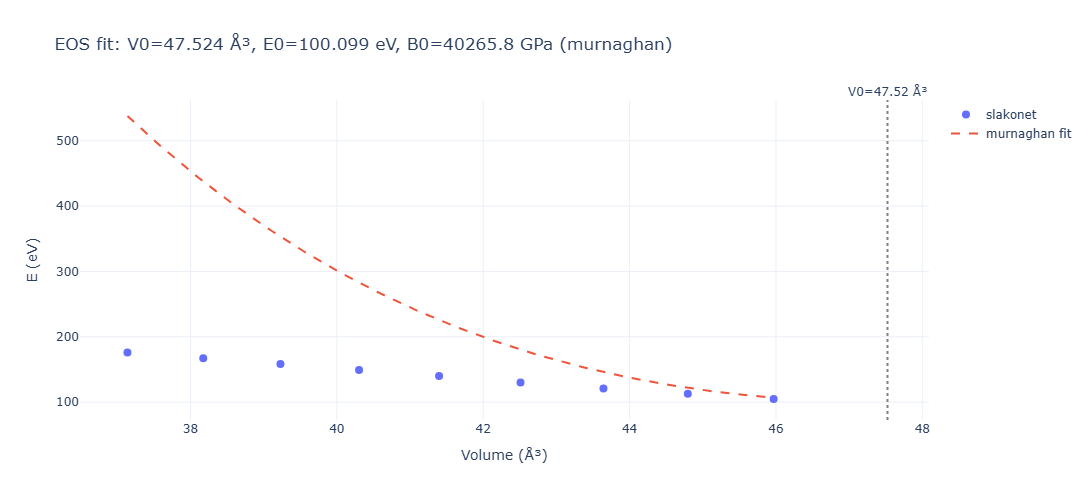

In [4]:
from slakonet.examples.full_demo import task_eos

task_eos(
  atoms, model, out='demo',
  strain_range=(-0.05, 0.02),   # same as your dx range
  n_points=9,
  supercell=(1,1,1),          # same as .make_supercell([2,2,2])
  kpoints=(3, 3, 3),
  use_scc=False,
  eos_kind='murnaghan',
).show()

In [2]:
task_bands_dos(atoms,model , out='demo').show()

Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
potential_energy tensor([0.1957], device='cuda:0')
electronic_energy tensor(-72.7001, device='cuda:0')
Bandgap: 0.266 eV
CBM: -3.742 eV
VBM: -4.008 eV
Gap: 0.266 eV (Fermi level at E = 0)
Plotly HTML saved to demo_bands.html
  wrote demo_bands.png and demo_bands.html


potential_energy tensor([0.], device='cuda:0')
electronic_energy tensor(-68.9003, device='cuda:0')
  wrote demo_fermi2d.html  (3 Fermi-crossing bands)


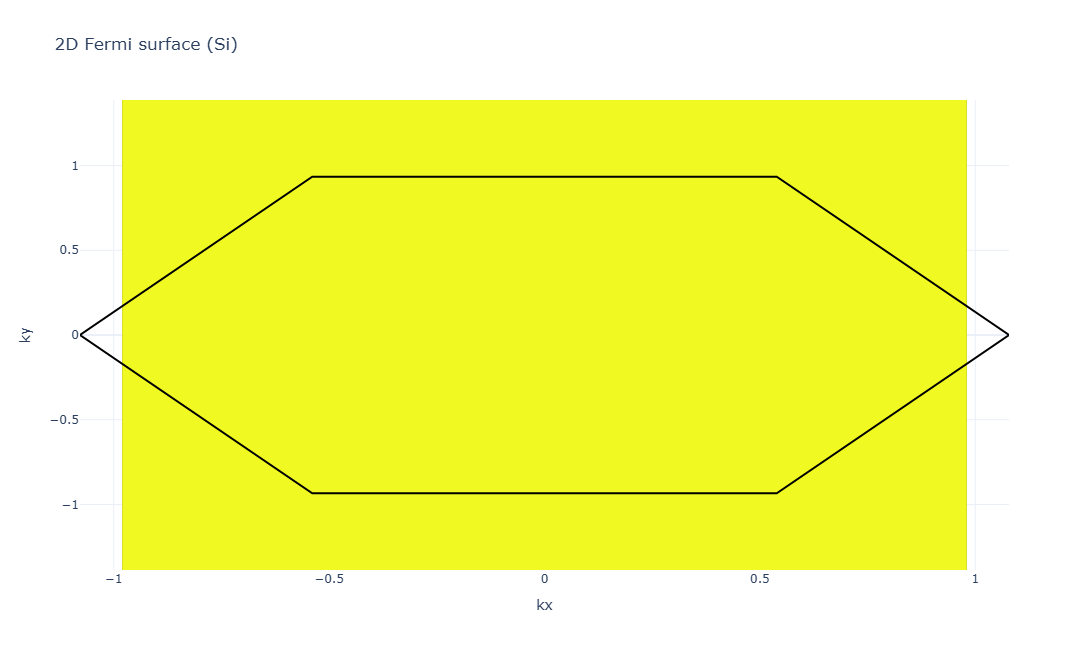

In [5]:
from slakonet.examples.full_demo import task_fermi2d
task_fermi2d(atoms, model, out='demo').show()

In [ ]:
from slakonet.examples.full_demo import task_fermi3d
task_fermi3d(atoms, model, out='demo').show()

potential_energy tensor([1.1805])
electronic_energy tensor(-75.4589, dtype=torch.float64, grad_fn=<SumBackward0>)
potential_energy tensor([0.7309])
electronic_energy tensor(-75.5463, dtype=torch.float64, grad_fn=<SumBackward0>)
potential_energy tensor([0.4475])
electronic_energy tensor(-75.3125, dtype=torch.float64, grad_fn=<SumBackward0>)
potential_energy tensor([0.2709])
electronic_energy tensor(-74.9268, dtype=torch.float64, grad_fn=<SumBackward0>)
potential_energy tensor([0.1621])
electronic_energy tensor(-74.8371, dtype=torch.float64, grad_fn=<SumBackward0>)
potential_energy tensor([0.0959])
electronic_energy tensor(-74.4727, dtype=torch.float64, grad_fn=<SumBackward0>)
potential_energy tensor([0.0561])
electronic_energy tensor(-73.3882, dtype=torch.float64, grad_fn=<SumBackward0>)
potential_energy tensor([0.0325])
electronic_energy tensor(-72.6721, dtype=torch.float64, grad_fn=<SumBackward0>)
potential_energy tensor([0.0186])
electronic_energy tensor(-71.9129, dtype=torch.float64

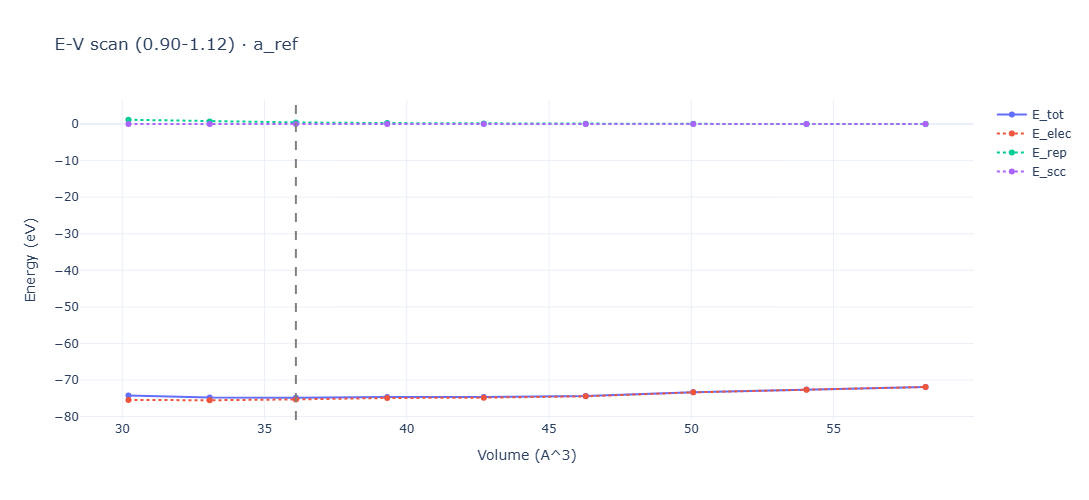

In [14]:
from slakonet.examples.full_demo import task_ev_curve
task_ev_curve(atoms, model, out='demo').show()

In [ ]:
# Collinear spin-polarized bands on the high-symmetry k-path
from slakonet.examples.full_demo import task_spin
task_spin(atoms, model, out='demo').show()


In [ ]:
# Spin-orbit-coupled bands on the high-symmetry k-path
from slakonet.examples.full_demo import task_soc
task_soc(atoms, model, out='demo').show()

  wrote demo_dielectric.html


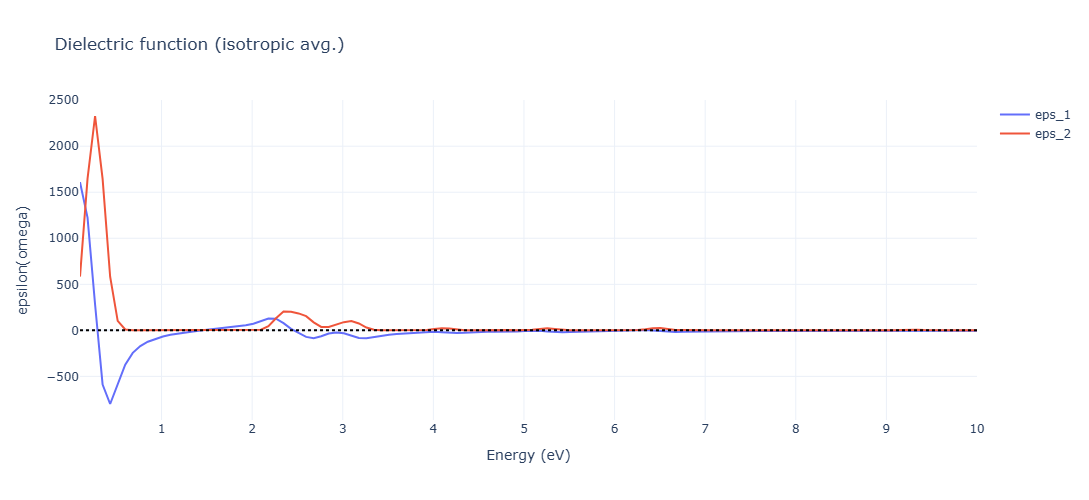

In [15]:
# Dielectric function: ε₁(ω), ε₂(ω) isotropic average
from slakonet.examples.full_demo import task_dielectric
task_dielectric(atoms, model, out='demo').show()

  wrote demo_scc.html  (Delta q = [4.210074422417165e-09, -1.5184069912521638e-08])


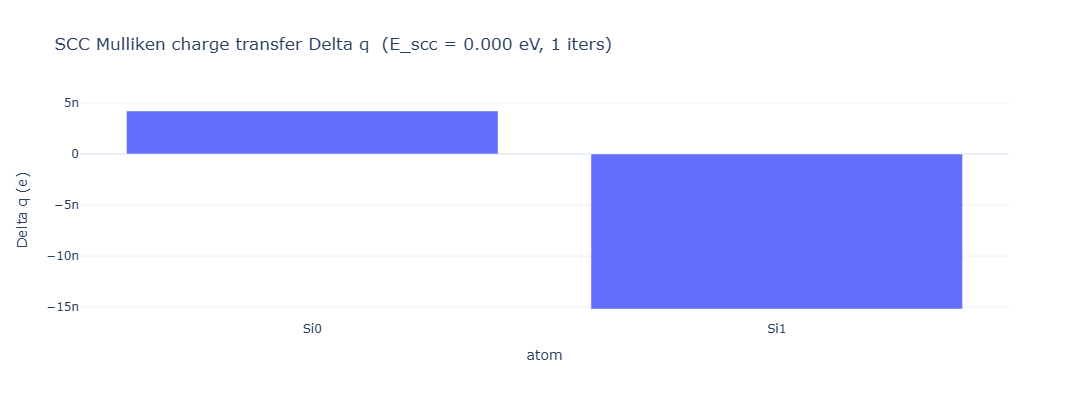

In [16]:
# SCC-DFTB Mulliken charge transfer bar chart (+ E_scc, iter count in title)
from slakonet.examples.full_demo import task_scc_charges
task_scc_charges(atoms, model, out='demo').show()

In [17]:
# Structural optimization (BFGS, 20 steps, fmax=0.05). Prints E_before/E_after/max|F|; no plot.
from slakonet.examples.full_demo import task_optimize
task_optimize(atoms, model, out='demo')

potential_energy tensor([0.1957], device='cuda:0', grad_fn=<AddBackward0>)
electronic_energy tensor(-71.9139, device='cuda:0', grad_fn=<SumBackward0>)
potential_energy tensor([0.1957], device='cuda:0', grad_fn=<AddBackward0>)
electronic_energy tensor(-71.9139, device='cuda:0', grad_fn=<SumBackward0>)
  E_before = -6.9957 eV   E_after = -6.9957 eV   dE = +0.0000 eV   max|F| = 0.0246 eV/A


In [18]:
import torch, numpy as np
from ase.build import bulk
from slakonet.atoms import Geometry
from slakonet.main import SimpleDftb

print(f"{'a (A)':>8} {'V (A^3)':>9} {'E_elec':>10} {'E_scc':>9} "
    f"{'E_rep':>9} {'E_tot':>10} {'gap':>6} {'iter':>4}")

rows = []
for a in [4.8, 5.0, 5.2, 5.43, 5.6, 5.8, 6.0, 6.3, 6.6, 7.0, 7.5]:
  at = bulk('Si', 'diamond', a=a)
  geom = Geometry.from_ase_atoms([at])
  calc = SimpleDftb(
      geom, model,
      kpoints=torch.tensor([3, 3, 3]),
      device='cpu',
      with_eigenvectors=True,
      compute_forces=False,
      include_dos_data=False,
      repulsive=True,
      alpha=1.0,
      use_scc=True,
  )
  res = calc.calculate()
  V = float(np.abs(np.linalg.det(at.cell)))
  info = calc._scc_info
  rows.append((a, V,
               float(res['electronic_energy']),
               float(info['E_scc_eV']),
               float(res['potential_energy']),
               float(res['energy']),
               float(res['bandgap']),
               info['n_iter']))
  print(f"{a:>8.2f} {V:>9.3f} {rows[-1][2]:>10.3f} {rows[-1][3]:>9.4f} "
        f"{rows[-1][4]:>9.3f} {rows[-1][5]:>10.3f} {rows[-1][6]:>6.2f} "
        f"{rows[-1][7]:>4d}")

   a (A)   V (A^3)     E_elec     E_scc     E_rep      E_tot    gap iter
potential_energy tensor([1.8468])
electronic_energy tensor(-75.1592, dtype=torch.float64, grad_fn=<SumBackward0>)
    4.80    27.648    -75.159    0.0000     1.847    -73.312   1.20    1
potential_energy tensor([0.9904])
electronic_energy tensor(-75.5210, dtype=torch.float64, grad_fn=<SumBackward0>)
    5.00    31.250    -75.521    0.0000     0.990    -74.531   1.30    1
potential_energy tensor([0.5209])
electronic_energy tensor(-75.4656, dtype=torch.float64, grad_fn=<SumBackward0>)
    5.20    35.152    -75.466    0.0000     0.521    -74.945   1.45    1
potential_energy tensor([0.2428])
electronic_energy tensor(-75.6560, dtype=torch.float64, grad_fn=<SumBackward0>)
    5.43    40.026    -75.656    0.0000     0.243    -75.413   1.80    1
potential_energy tensor([0.1358])
electronic_energy tensor(-74.3155, dtype=torch.float64, grad_fn=<SumBackward0>)
    5.60    43.904    -74.316    0.0000     0.136    -74.180   1.

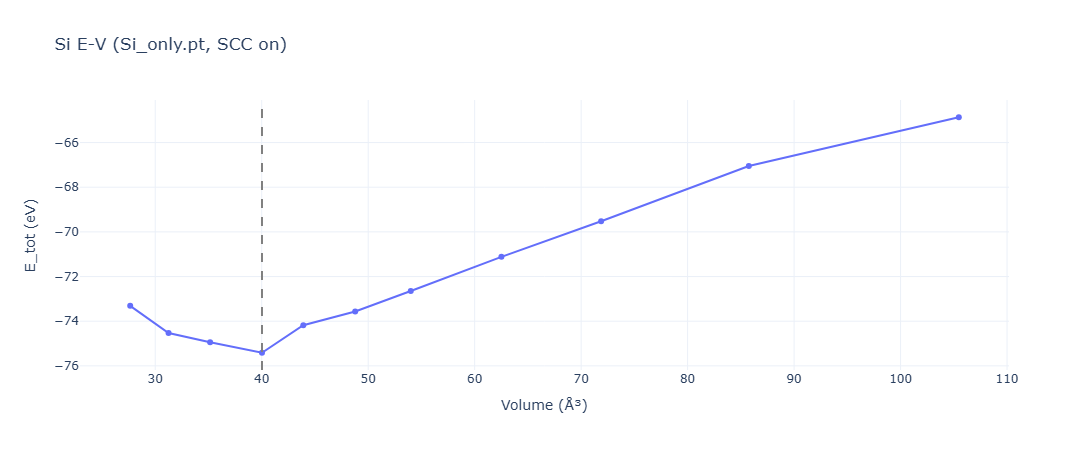

In [19]:
import plotly.graph_objects as go
import numpy as np
arr = np.array(rows)
V, Etot = arr[:, 1], arr[:, 5]
fig = go.Figure(go.Scatter(x=V, y=Etot, mode='lines+markers', name='E_tot'))
fig.add_vline(x=V[np.argmin(Etot)], line=dict(color='gray', dash='dash'))
fig.update_layout(xaxis_title='Volume (Å³)', yaxis_title='E_tot (eV)',
                title='Si E-V (Si_only.pt, SCC on)',
                template='plotly_white', width=800, height=450)
fig.show()

## One-shot: every task at once

`show=True` renders the Plotly figures inline; the same HTMLs are also saved to disk.

In [9]:
# figs = run_all(
#     jid='JVASP-1002',
#     skip={'fermi3d', 'dielectric'},  # the two slowest; remove to include
#     show=True,
# )

## Or call tasks individually

Any task signature is `task(atoms, model, out_prefix) -> plotly.graph_objects.Figure | None`.


Obtaining 3D dataset 76k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699
Loading the zipfile...
Loading completed.
Loading cached model from /home/kamalch/.cache/atomgptlab/slakonet/slakonet_v0/slakonet_v0.pt
✅ Compact model loaded from: /home/kamalch/.cache/atomgptlab/slakonet/slakonet_v0/slakonet_v0.pt
Total time: 12.32s
potential_energy tensor([0.], device='cuda:0')
electronic_energy tensor(-68.9003, device='cuda:0')
  wrote demo_fermi2d.html  (3 Fermi-crossing bands)


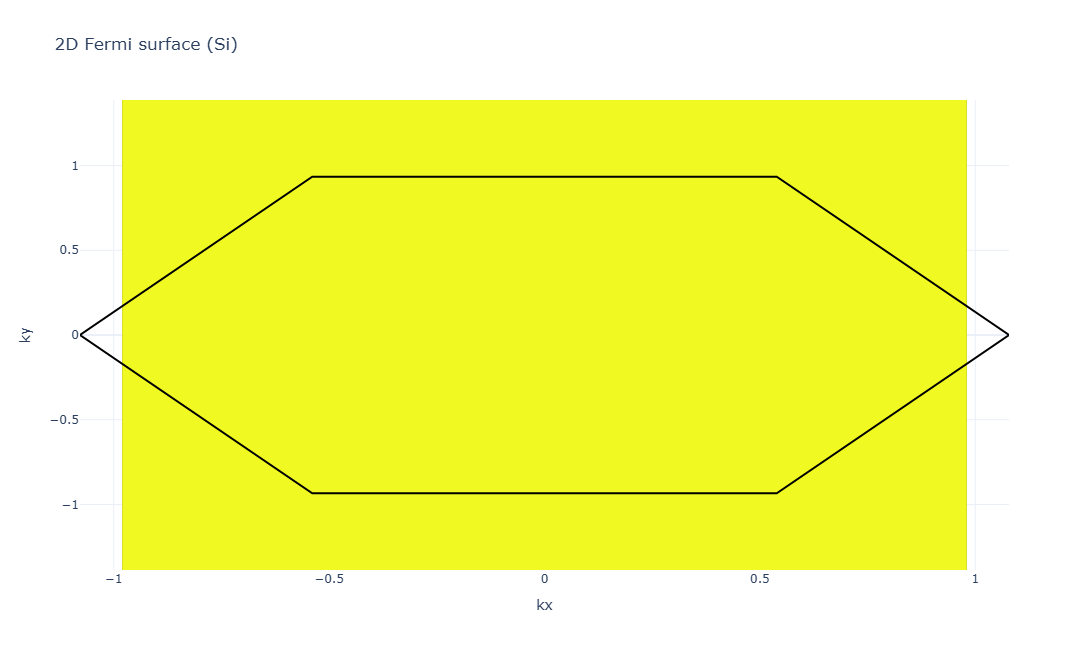

In [3]:
from slakonet.examples.full_demo import (
    task_bands_dos, task_fermi2d, task_fermi3d, task_ev_curve,
    task_spin, task_soc, task_dielectric, task_scc_charges, task_optimize,
)
from slakonet.optim import default_model, get_atoms

atoms, opt_gap, _ = get_atoms('JVASP-1002')
model = default_model()

fig = task_fermi2d(atoms, model, out='demo')
fig.show()

## Open a previously-saved HTML inline

The band-structure task is still matplotlib-first but also writes a full-featured Plotly HTML. Display it with an IFrame:

In [ ]:
from IPython.display import IFrame
IFrame('JVASP-1002_bands.html', width='100%', height=520)